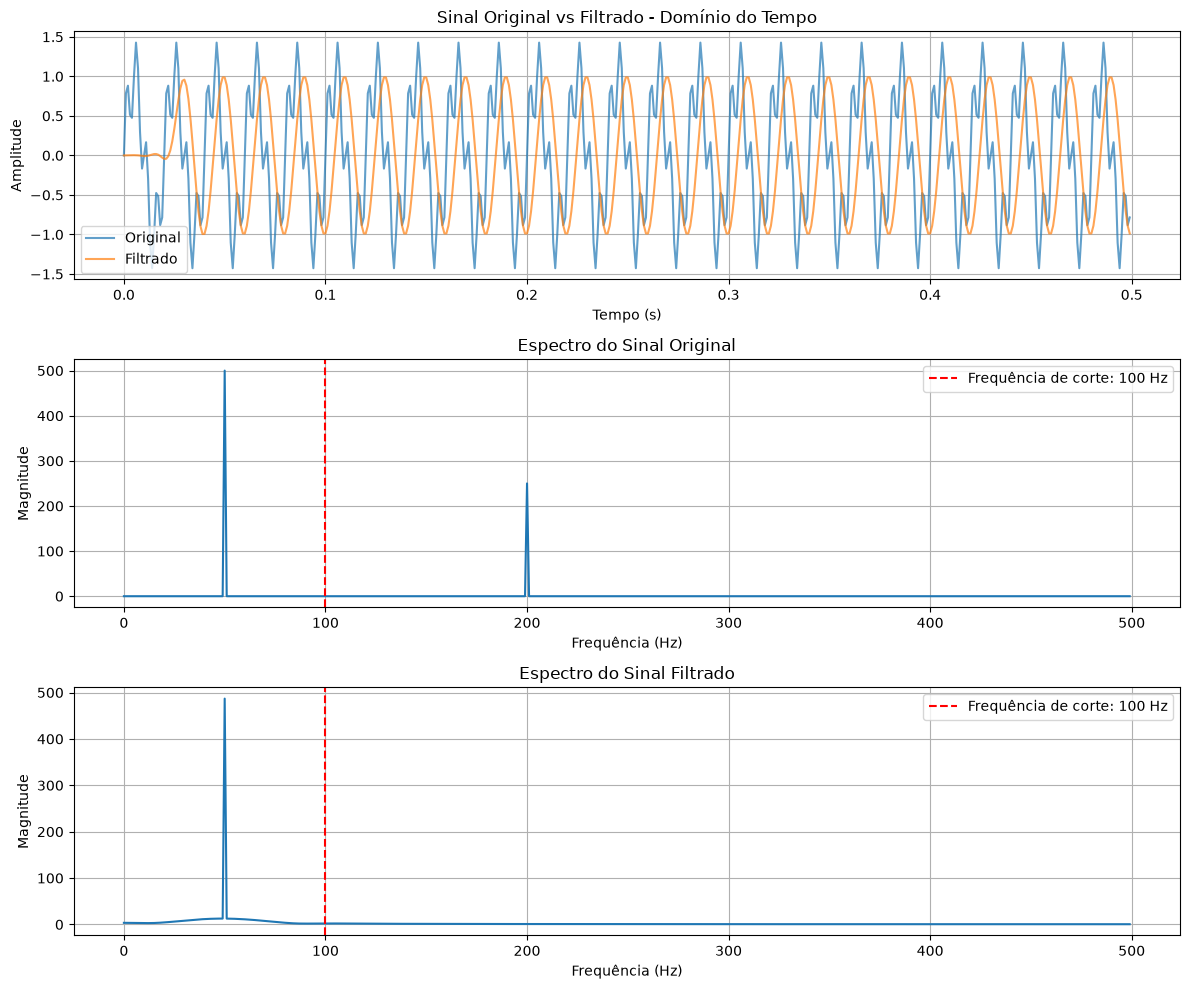

Análise das componentes espectrais:
Frequência 50 Hz presente no original: Não
Frequência 50 Hz presente no filtrado: Não
Frequência 200 Hz presente no original: Não
Frequência 200 Hz presente no filtrado: Não


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq

# Parâmetros de simulação
fs = 1000  # Frequência de amostragem (Hz)
t = np.arange(0, 1, 1/fs)  # Vetor de tempo

# Sinal composto: duas senoides
f1 = 50   # Frequência 50 Hz
f2 = 200  # Frequência 200 Hz
sinal = np.sin(2*np.pi*f1*t) + 0.5*np.sin(2*np.pi*f2*t)

# Projeto do filtro passa-baixa FIR
fc = 100  # Frequência de corte (Hz)
ordem = 50
b = signal.firwin(ordem, fc, fs=fs, window='hamming')

# Aplicar o filtro
sinal_filtrado = signal.lfilter(b, [1.0], sinal)

# Análise no domínio da frequência
N = len(sinal)
freq = fftfreq(N, 1/fs)
magnitude_original = np.abs(fft(sinal))
magnitude_filtrada = np.abs(fft(sinal_filtrado))

# Gráficos
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Sinal no domínio do tempo
axes[0].plot(t[:500], sinal[:500], label='Original', alpha=0.7)
axes[0].plot(t[:500], sinal_filtrado[:500], label='Filtrado', alpha=0.7)
axes[0].set_xlabel('Tempo (s)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Sinal Original vs Filtrado - Domínio do Tempo')
axes[0].legend()
axes[0].grid()

# Espectro original
axes[1].plot(freq[:N//2], magnitude_original[:N//2])
axes[1].set_xlabel('Frequência (Hz)')
axes[1].set_ylabel('Magnitude')
axes[1].set_title('Espectro do Sinal Original')
axes[1].grid()
axes[1].axvline(fc, color='r', linestyle='--', label=f'Frequência de corte: {fc} Hz')
axes[1].legend()

# Espectro filtrado
axes[2].plot(freq[:N//2], magnitude_filtrada[:N//2])
axes[2].set_xlabel('Frequência (Hz)')
axes[2].set_ylabel('Magnitude')
axes[2].set_title('Espectro do Sinal Filtrado')
axes[2].grid()
axes[2].axvline(fc, color='r', linestyle='--', label=f'Frequência de corte: {fc} Hz')
axes[2].legend()

plt.tight_layout()
plt.show()

# Verificação das componentes remanescentes
print("Análise das componentes espectrais:")
print(f"Frequência 50 Hz presente no original: {'Sim' if magnitude_original[np.argmax(freq[:N//2] > 48) * 2] > 100 else 'Não'}")
print(f"Frequência 50 Hz presente no filtrado: {'Sim' if magnitude_filtrada[np.argmax(freq[:N//2] > 48) * 2] > 100 else 'Não'}")
print(f"Frequência 200 Hz presente no original: {'Sim' if magnitude_original[np.argmax(freq[:N//2] > 198) * 2] > 100 else 'Não'}")
print(f"Frequência 200 Hz presente no filtrado: {'Sim' if magnitude_filtrada[np.argmax(freq[:N//2] > 198) * 2] > 100 else 'Não'}")

# Discussão dos Resultados
O filtro passa-baixa projetado com frequência de corte em 100 Hz remove efetivamente a componente de 200 Hz, mantendo a componente de 50 Hz. A janela de Hamming utilizada no projeto do filtro FIR garante boa seletividade com lóbulos laterais reduzidos. Observa-se no domínio do tempo que o sinal filtrado apresenta a forma senoidal suave da componente de baixa frequência, com a componente de alta frequência eliminada